# Завантаження та підготовка даних

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import kagglehub
import warnings
warnings.filterwarnings("ignore")

np.random.seed(28)

# завантажуємо датасет з kaggle
path = kagglehub.dataset_download("zaheenhamidani/ultimate-spotify-tracks-db")
df = pd.read_csv(f"{path}/SpotifyFeatures.csv") # читаємо csv файл

print("\nперші 5 рядків датасету:")
display(df.head())
print("\nінформація про датасет:")
df.info()
print("\nопис числових колонок:")
display(df.describe())

# обираємо тільки числові характеристики аудіо
features = ["danceability", "energy", "loudness", "speechiness", "acousticness", "instrumentalness", "liveness", "valence", "tempo"]
X = df[features].copy() # матриця ознак


print(f"\nрозмірність матриці ознак до стандартизації: {X.shape}")

# стандартизація
scaler = StandardScaler()
# для кожної ознаки віднімається середнє і ділиться на стандартне відхилення
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features, index=df.index)
print("\nдані стандартизовано!")

print("середні значення після стандартизації:")
print(X_scaled_df.mean().round(4))
print("\nстандартні відхилення після стандартизації:")
print(X_scaled_df.std(ddof=0).round(4))


# фільтрація популярних треків
mask = df["popularity"] >= 85

# відфільтровані дані
df_popular = df[mask].copy()
X_popular = X_scaled_df.loc[mask].copy()

# виводимо кількість популярних треків і розмірність після фільтрації
print(f"\nкількість треків з popularity >= 85: {df_popular.shape[0]}")
print(f"розмірність таблиці після фільтрації: {df_popular.shape}")
print(f"розмірність матриці ознак популярних треків: {X_popular.shape}")

# перші рядки вже відфільтрованої таблиці
print("\nперші 5 популярних треків:")
display(df_popular.head())

Using Colab cache for faster access to the 'ultimate-spotify-tracks-db' dataset.

перші 5 рядків датасету:


,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390



інформація про датасет:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232725 entries, 0 to 232724
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   genre             232725 non-null  object 
 1   artist_name       232725 non-null  object 
 2   track_name        232724 non-null  object 
 3   track_id          232725 non-null  object 
 4   popularity        232725 non-null  int64  
 5   acousticness      232725 non-null  float64
 6   danceability      232725 non-null  float64
 7   duration_ms       232725 non-null  int64  
 8   energy            232725 non-null  float64
 9   instrumentalness  232725 non-null  float64
 10  key               232725 non-null  object 
 11  liveness          232725 non-null  float64
 12  loudness          232725 non-null  float64
 13  mode              232725 non-null  object 
 14  speechiness       232725 non-null  float64
 15  tempo             232725 non-null  float64


,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,232725.000000,232725.000000,232725.000000,2.327250e+05,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000
mean,41.127502,0.368560,0.554364,2.351223e+05,0.570958,0.148301,0.215009,-9.569885,0.120765,117.666585,0.454917
std,18.189948,0.354768,0.185608,1.189359e+05,0.263456,0.302768,0.198273,5.998204,0.185518,30.898907,0.260065
min,0.000000,0.000000,0.056900,1.538700e+04,0.000020,0.000000,0.009670,-52.457000,0.022200,30.379000,0.000000
25%,29.000000,0.037600,0.435000,1.828570e+05,0.385000,0.000000,0.097400,-11.771000,0.036700,92.959000,0.237000
50%,43.000000,0.232000,0.571000,2.204270e+05,0.605000,0.000044,0.128000,-7.762000,0.050100,115.778000,0.444000
75%,55.000000,0.722000,0.692000,2.657680e+05,0.787000,0.035800,0.264000,-5.501000,0.105000,139.054000,0.660000
max,100.000000,0.996000,0.989000,5.552917e+06,0.999000,0.999000,1.000000,3.744000,0.967000,242.903000,1.000000



розмірність матриці ознак до стандартизації: (232725, 9)

дані стандартизовано!
середні значення після стандартизації:
danceability       -0.0
energy              0.0
loudness           -0.0
speechiness        -0.0
acousticness        0.0
instrumentalness    0.0
liveness           -0.0
valence             0.0
tempo              -0.0
dtype: float64

стандартні відхилення після стандартизації:
danceability        1.0
energy              1.0
loudness            1.0
speechiness         1.0
acousticness        1.0
instrumentalness    1.0
liveness            1.0
valence             1.0
tempo               1.0
dtype: float64

кількість треків з popularity >= 85: 417
розмірність таблиці після фільтрації: (417, 18)
розмірність матриці ознак популярних треків: (417, 9)

перші 5 популярних треків:


,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
9026,Dance,Ariana Grande,"break up with your girlfriend, i'm bored",4kV4N9D1iKVxx1KLvtTpjS,99,0.0421,0.726,190440,0.554,0.000000,F,0.1060,-5.290,Minor,0.0917,169.999,4/4,0.335
9027,Dance,Ariana Grande,7 rings,14msK75pk3pA33pzPVNtBF,100,0.5780,0.725,178640,0.321,0.000000,C#,0.0884,-10.744,Minor,0.3230,70.142,4/4,0.319
9028,Dance,Halsey,Without Me,5p7ujcrUXASCNwRaWNHR1C,97,0.2970,0.752,201661,0.488,0.000009,F#,0.0936,-7.050,Major,0.0705,136.041,4/4,0.533
9029,Dance,Ariana Grande,needy,1TEL6MlSSVLSdhOSddidlJ,92,0.7800,0.647,171573,0.309,0.000007,G,0.2020,-7.948,Minor,0.0366,87.045,4/4,0.195
9030,Dance,Ariana Grande,NASA,4uTvPEr01pjTbZgl7jcKBD,91,0.4510,0.747,182000,0.458,0.000000,F#,0.2520,-6.891,Major,0.3030,75.029,4/4,0.470


# Підбір оптимальної кількості кластерів (k) — метод ліктя

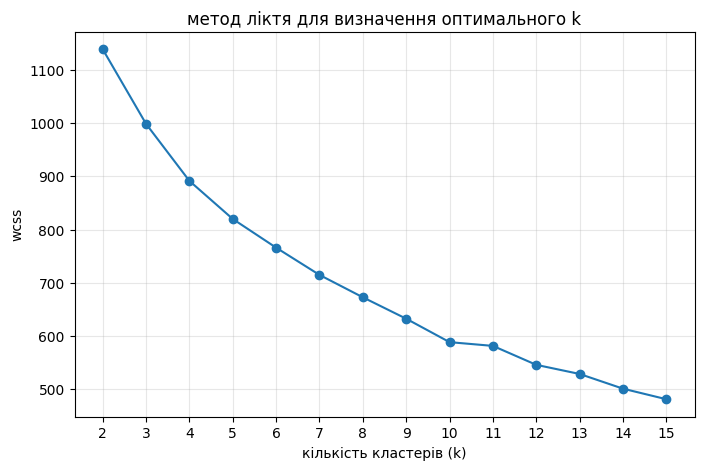

In [ ]:
from sklearn.cluster import KMeans

# діапазон значень k (кількість кластерів)
k_values = range(2, 16)

wcss_values = []

# перебираємо різні значення k
for k in k_values:
    # модель k-means з k кластерами
    kmeans = KMeans(n_clusters = k, random_state = 28, n_init = 10)

    # навчаємо модель на стандартизованих даних популярних треків
    kmeans.fit(X_popular)

    # зберігаємо суму квадратів відстаней до центрів кластерів
    wcss_values.append(kmeans.inertia_)

# графік методу ліктя
plt.figure(figsize=(8, 5))
plt.plot(k_values, wcss_values, marker='o')

plt.title("метод ліктя для визначення оптимального k")
plt.xlabel("кількість кластерів (k)")
plt.ylabel("wcss")

plt.xticks(k_values)
plt.grid(alpha = 0.3)

plt.show()

# Побудова кластеризації

кількість треків у кожному кластері:
кластер 0: 40 треків (9.6%)
кластер 1: 71 треків (17.0%)
кластер 2: 69 треків (16.5%)
кластер 3: 66 треків (15.8%)
кластер 4: 81 треків (19.4%)
кластер 5: 57 треків (13.7%)
кластер 6: 33 треків (7.9%)


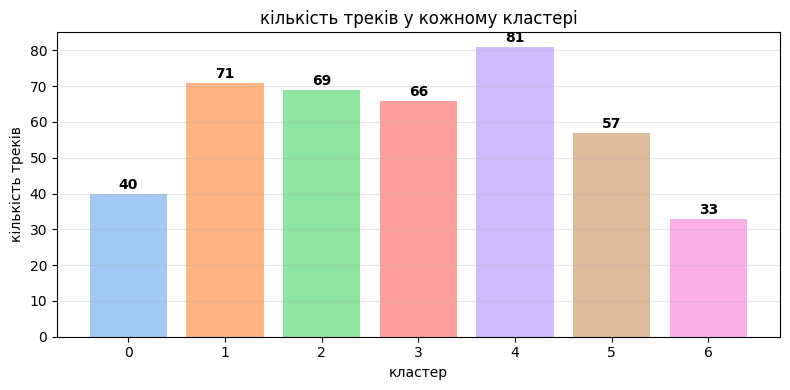

In [ ]:
OPTIMAL_K = 7

# фінальна модель k-means з обраним k
kmeans_final = KMeans(n_clusters = OPTIMAL_K, random_state = 28, n_init = 10)

# кластеризація популярних треків
cluster_labels = kmeans_final.fit_predict(X_popular)

# додаєм мітки кластерів у таблицю популярних треків як нову колонку
df_popular = df_popular.copy()
df_popular["cluster"] = cluster_labels

# рахуємо кількість треків у кожному кластері
cluster_counts = df_popular["cluster"].value_counts().sort_index()

print("кількість треків у кожному кластері:")
for cluster_id, count in cluster_counts.items():
    print(f"кластер {cluster_id}: {count} треків ({count / len(df_popular) * 100:.1f}%)")

# графік розподілу треків за кластерами
plt.figure(figsize = (8, 4))
bars = plt.bar(cluster_counts.index, cluster_counts.values, color = sns.color_palette("pastel", OPTIMAL_K))

plt.title("кількість треків у кожному кластері")
plt.xlabel("кластер")
plt.ylabel("кількість треків")
plt.xticks(range(OPTIMAL_K))
plt.grid(alpha = 0.3, axis = "y")

for bar, count in zip(bars, cluster_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, str(count), ha = "center",  va = "bottom", fontweight = "bold")

plt.tight_layout()
plt.show()

# Візуалізація кластерів у просторі головних компонент

In [ ]:
from sklearn.decomposition import PCA
import plotly.express as px

# модель pca для зменшення розмірності до 2
pca2 = PCA(n_components = 2)

# нові координати для 2д візуалізації
coords_2d = pca2.fit_transform(X_popular)

df_2d = pd.DataFrame({
    'PC1': coords_2d[:, 0], # перша головна компонента
    'PC2': coords_2d[:, 1], # друга головна компонента
    'cluster': df_popular['cluster'].astype(str), # номер кластера як категорія
    'track_name': df_popular['track_name'], # назва треку
    'popularity': df_popular['popularity']  # популярність
})

# 2д графік
fig_2d = px.scatter(df_2d, x = 'PC1', y = 'PC2', color = 'cluster', hover_data = ['track_name', 'popularity'],
    title = 'pca 2d - кластери популярних треків (popularity >= 85)',
    labels = {'PC1': f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)', 'PC2': f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)'},
    color_discrete_sequence = px.colors.qualitative.Bold, opacity = 0.8)

fig_2d.update_traces(marker = dict(size = 6))
fig_2d.show()



# модель pca для 3 компонент
pca3 = PCA(n_components = 3)

# координати у 3д просторі
coords_3d = pca3.fit_transform(X_popular)

# dataframe для 3д візуалізації
df_3d = pd.DataFrame({'PC1': coords_3d[:, 0], 'PC2': coords_3d[:, 1], 'PC3': coords_3d[:, 2],
    'cluster': df_popular['cluster'].astype(str), 'track_name': df_popular['track_name'], 'popularity': df_popular['popularity']})

# 3д графік
fig_3d = px.scatter_3d( df_3d, x = 'PC1', y = 'PC2', z = 'PC3', color = 'cluster', hover_data = ['track_name', 'popularity'],
    title='pca 3d - кластери популярних треків (popularity >= 85)',
    labels={'PC1': f'PC1 ({pca3.explained_variance_ratio_[0]*100:.1f}%)', 'PC2': f'PC2 ({pca3.explained_variance_ratio_[1]*100:.1f}%)',
        'PC3': f'PC3 ({pca3.explained_variance_ratio_[2]*100:.1f}%)'},
    color_discrete_sequence=px.colors.qualitative.Bold, opacity = 0.8)

# зменшуємо розмір точок для 3d
fig_3d.update_traces(marker=dict(size = 4))

fig_3d.show()


# Аналіз кластерів

середні стандартизовані значення ознак по кластерах:
         danceability    energy  loudness  speechiness  acousticness  \
cluster                                                                
0            1.032610  0.296226  0.549017    -0.026130     -0.775448   
1            0.312496  0.152845  0.633684    -0.042418     -0.222561   
2            1.716245 -0.334962  0.240955     0.615013     -0.462067   
3            1.032231  0.447767  0.668273     0.232593     -0.840474   
4            0.937692  0.705461  0.862029    -0.206959     -0.434394   
5            0.487467  0.400309  0.696255    -0.177304     -0.695099   
6            0.670193 -0.348010  0.290498    -0.265309      0.684230   

         instrumentalness  liveness   valence     tempo  
cluster                                                  
0               -0.483397  1.141692 -0.095137  0.109395  
1               -0.468007 -0.355171 -0.274855 -0.785013  
2               -0.478025 -0.355604 -0.181458 -0.383199  
3       

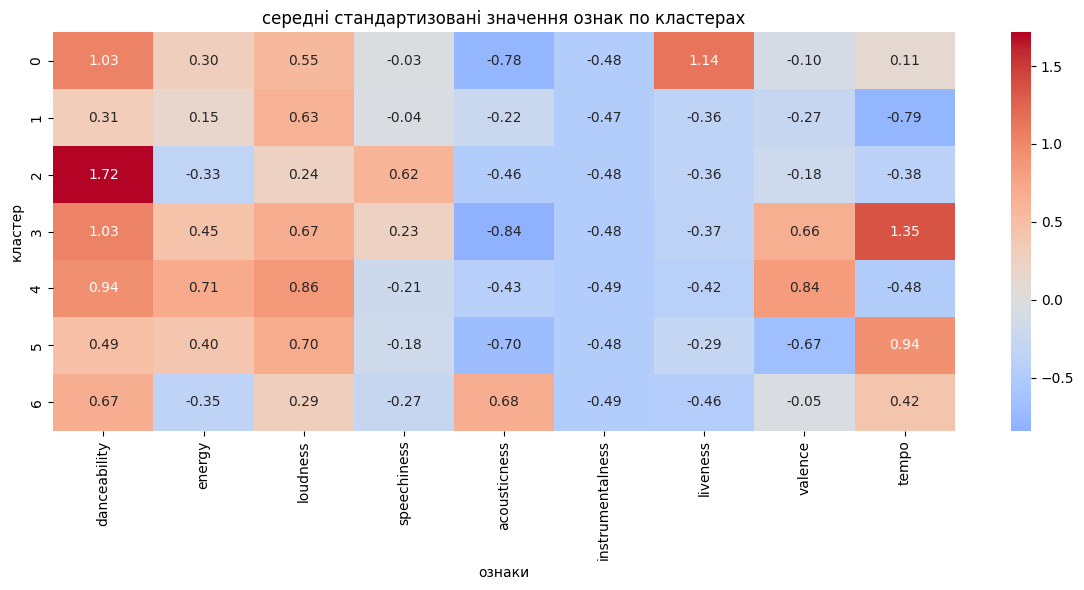

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# таблиця стандартизованих ознак
# dataframe зі стандартизованих даних
df_scaled = pd.DataFrame(X_popular, columns=features)

# мітки кластерів
df_scaled["cluster"] = df_popular["cluster"].values

# середні значення по кластерах
cluster_stats = df_scaled.groupby("cluster")[features].mean()

print("середні стандартизовані значення ознак по кластерах:")
print(cluster_stats)

# heatmap
plt.figure(figsize = (12, 6))

sns.heatmap( cluster_stats, annot = True, fmt = ".2f", cmap = "coolwarm", center = 0 )

plt.title("середні стандартизовані значення ознак по кластерах")
plt.xlabel("ознаки")
plt.ylabel("кластер")

plt.tight_layout()
plt.show()

Кластер 0 має танцювальні треки з дуже високим показником liveness, що характерно для популярних живих виступів.

Кластер 1 об’єднує помірно популярні пісні з низьким темпом, ймовірно меланхолійні або повільна поп-музика.

Кластер 2 - найбільш танцювальні треки з високим рівнем speechiness, що вказує на наявність репу або хіп-хопу.

Кластер 3 представляє енергійні та позитивні хіти з найвищим темпом (tempo) і valence, ймоірно для вечірок та активного відпочинку.

Кластер 4 складається з дуже потужних та енергійних композицій (найвищі енергія та гучність) з позитивним настроєм, властиве жанру рок.

Кластер 5 - це ритмічні треки з високим темпом, але низьким емоційним забарвленням (valence), що може відповідати агресивній електронній музиці або похмурим танцювальним жанрам.

Кластер 6 є єдиною групою з високою акустичністю та низькою енергією, що відповідає акустичним баладам, інді-фолку або спокійним інструментальним пісням.